In [94]:
import os
import torch
import torchvision
import torch.nn.functional as F
from utils.dataset import Dataset
from fr_models.get_model import getmodel
from tqdm import tqdm
from AdvFaceGAN import Generator
from torchmetrics.functional import structural_similarity_index_measure as ssim
from torchmetrics.functional import peak_signal_noise_ratio as psnr
from fr_models.config import threshold_lfw
import numpy as np
import pickle

# 非需要不加载数据集
def prepDataset(test_set, test_batch_size):
    if test_set is not None:
        return test_set
    print("---------------------Load test set-----------------------")
    test_set = Dataset("C:/yy/datasets/CASIA-WebFace/casia-aligned-112x112/")
    print("------------------start batch queue----------------------")
    test_set.start_batch_queue(
        test_batch_size,
        batch_format="random_samples",
        transforms=torchvision.transforms.Compose([
            torchvision.transforms.Resize((112,112)),  # 调整图片大小
            torchvision.transforms.ToTensor(),  # 图片转为Tensor [0,1]
            torchvision.transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 归一化
        ]),
        num_threads=3,
    )
    return test_set

# 存储评估结果
evaluation_results = {}
test_model_dirs = [
    'target 1 8白盒 无stloss',
   'target 2 8白盒 无stloss',
   'target 3 8白盒 无stloss',
   'target 4 8白盒 无stloss',
   'target 5 8白盒 无stloss',
   'target 6 8白盒 无stloss',
   'target 7 8白盒 无stloss',
   'target 8 8白盒 无stloss',
   'target 4 8白盒 奇怪ssim 93ssim',
   'target 4 8白盒 奇怪ssim 97ssim',
   'target 4 7白盒 奇怪ssim 100ssim',
   'target 5 8白盒 92ssim',
   'target 5 8白盒 奇怪ssim 95ssim',
   'target 8 8白盒 90ssim',
   'target 8 8白盒 奇怪ssim 92ssim',
   'target 5 8白盒 无stloss 双身份损失0.15',
   'target 5 8白盒 无stloss 双身份损失0.15',
   'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15',
   'target 8 8白盒 奇怪ssim 90ssim 双身份损失0.2',
   'target 8 8白盒 91ssim 双身份损失0.3',
]
test_epoch_ids = [990,1490,990,990,990,990,990,990,1490,1130,1120,1160,1660,1100,1490,1110,990,2490,1080,1150]

test_batch_size = 30
# 懒加载
test_set=None
# 添加新fr模型后请把save_path下的pkl都删掉再运行一遍
target_model_name_list = ['CosFace',
                         'SphereFace',
                         'MobileFace',
                         'FaceNet-casia',
                         'ArcFace',
                         'ResNet50',
                         'IR50-PGDSoftmax',
                         'IR50-TradesCosFace',
                         # 'IR50-Softmax-BR',
                         # 'IR50-Softmax-JPEG',
                         # 'IR50-Softmax-RP',
                         'testir152',]
with torch.no_grad():
    # 遍历每个攻击模型
    for model_idx, (model_dir, epoch_id) in enumerate(zip(test_model_dirs, test_epoch_ids)):
        save_path = f"./data/temp/{model_dir} {epoch_id}.pkl"
        # 检查结果文件是否存在
        if os.path.exists(save_path):
            print(f"结果文件 {save_path} 已存在，正在加载数据...")
            # 加载保存的 pickle 数据
            with open(save_path, 'rb') as pickle_file:
                evaluation_results[f'{model_dir} {epoch_id}'] = pickle.load(pickle_file)
            print(f"结果文件 {save_path} 已加载")
            continue
        print(f"Loading attack model: {model_dir}, epoch {epoch_id}")
        fake_generator = Generator(is_target=True).eval().cuda()
        model_generator_dict = torch.load('./save_dir/'+model_dir +'/model/'+ '%05d_generator.pth' % epoch_id, weights_only=True)
        fake_generator.load_state_dict(model_generator_dict)
        print("---------------------------------------------------------")
        print(f"Evaluating attack model {model_dir} {epoch_id}")
        print("---------------------------------------------------------")
        evaluation_results[f'{model_dir} {epoch_id}']={}
        
        # 遍历目标模型
        for frmodel_name in target_model_name_list:
            print(f"-----------------start evaluate {frmodel_name}-------------------")
            th = threshold_lfw[frmodel_name]['cos']
            ssim_scores = []
            psnr_scores = []
            mse_scores = []
            true_perts_score = []
            FAR_simi_scores = []
            TAR_simi_scores = []
            source_simi_scores = []
            target_simi_scores = []
            source2_simi_scores = []
            source3_simi_scores = []
            target2_simi_scores = []
            target3_simi_scores = []
            frmodel, img_shape = getmodel(frmodel_name)
            test_epoch_size = 6000 // test_batch_size
            for _ in tqdm(range(test_epoch_size)):
                # get batch data
                test_set=prepDataset(test_set, test_batch_size)
                batch = test_set.pop_batch_queue()
                # Call the generator to generate adversary faces
                source_faces = batch['sources'].cuda()
                source2_faces = batch['sources2'].cuda()
                source3_faces = batch['sources3'].cuda()
                target_faces = batch['targets'].cuda()
                target2_faces = batch['targets2'].cuda()
                target3_faces = batch['targets3'].cuda()
                perts, fake_afters = fake_generator(sources=source_faces, targets=target_faces)
                # calculate visual quality metric
                source_faces = (source_faces * 0.5 + 0.5)*255
                source2_faces = (source2_faces * 0.5 + 0.5)*255
                source3_faces = (source3_faces * 0.5 + 0.5)*255
                target_faces = (target_faces * 0.5 + 0.5)*255
                target2_faces = (target2_faces * 0.5 + 0.5)*255
                target3_faces = (target3_faces * 0.5 + 0.5)*255
                fake_afters = (fake_afters * 0.5 + 0.5)*255
                for i in range(source_faces.size(0)):  # 遍历 batch 中的每一对图像
                    source = source_faces[i].unsqueeze(0)  # 转换为 (batch, channels, height, width,) 格式
                    fake = fake_afters[i].unsqueeze(0)  # 转换为 (batch, channels, height, width) 格式
                    # 计算单张图像的 SSIM
                    ssim_scores.append(ssim(source, fake).item())
                    psnr_scores.append(psnr(source, fake).item())
                    mse_scores.append(F.mse_loss(source, fake).item())
                    true_perts_score.append(torch.norm(perts[i]).item())
                # extract face embedding
                emb_source = frmodel.forward(F.interpolate(source_faces, size=img_shape, mode='bilinear'))
                emb_source2 = frmodel.forward(F.interpolate(source2_faces, size=img_shape, mode='bilinear'))
                emb_source3 = frmodel.forward(F.interpolate(source3_faces, size=img_shape, mode='bilinear'))
                emb_target = frmodel.forward(F.interpolate(target_faces, size=img_shape, mode='bilinear'))
                emb_target2 = frmodel.forward(F.interpolate(target2_faces, size=img_shape, mode='bilinear'))
                emb_target3 = frmodel.forward(F.interpolate(target3_faces, size=img_shape, mode='bilinear'))
                emb_fake_after = frmodel.forward(F.interpolate(fake_afters, size=img_shape, mode='bilinear'))
                #  evaluation cosine similarity
                FAR_simi_scores.extend(torch.cosine_similarity(emb_source, emb_target).cpu().detach().tolist())
                TAR_simi_scores.extend(torch.cosine_similarity(emb_source, emb_source2).cpu().detach().tolist())
                source_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source).cpu().detach().tolist())
                source2_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source2).cpu().detach().tolist())
                source3_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_source3).cpu().detach().tolist())
                target_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target).cpu().detach().tolist())
                target2_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target2).cpu().detach().tolist())
                target3_simi_scores.extend(torch.cosine_similarity(emb_fake_after, emb_target3).cpu().detach().tolist())
            del frmodel
            torch.cuda.empty_cache()
            print(frmodel_name, " benchmark threshold_lfw:%f" % threshold_lfw[frmodel_name]['cos'])
            print(frmodel_name, " benchmark rate:%f" % threshold_lfw[frmodel_name]['cos_acc'])
            print(frmodel_name, " before 1-FAR:%f" % np.mean(np.array(FAR_simi_scores) < th))
            print(frmodel_name, " before TAR:%f" % np.mean(np.array(TAR_simi_scores) > th))
            print(frmodel_name, " true pert:%f" % np.mean(true_perts_score))
            print(frmodel_name, " mean source & target:%.4f & %.4f" % (np.mean(source_simi_scores), np.mean(target_simi_scores)))
            print(frmodel_name, " average ssim:%f" % np.mean(ssim_scores))
            print(frmodel_name, " average psnr:%f" % np.mean(psnr_scores))
            print(frmodel_name, " average mse:%f" % np.mean(mse_scores))
            print(frmodel_name, " attack success rate1:%f" % np.mean(np.array(target_simi_scores) > th))
            print(frmodel_name, " attack success rate2:%f" % np.mean((np.array(source_simi_scores) > th) & (np.array(target_simi_scores) > th)))
            print(frmodel_name, " attack success rate3:%f" % np.mean(((np.array(source2_simi_scores) > th) | (np.array(source3_simi_scores) > th))& ((np.array(target2_simi_scores) > th) | (np.array(target3_simi_scores) > th))))
            # 存储当前目标模型的评估结果
            evaluation_results[f'{model_dir} {epoch_id}'][f'{frmodel_name}'] = {
                "threshold": th,
                "FAR": np.mean(np.array(FAR_simi_scores) < th),
                "TAR": np.mean(np.array(TAR_simi_scores) > th),
                "true_pert": true_perts_score,
                "mean_source": source_simi_scores,
                "mean_target": target_simi_scores,
                "average_ssim": ssim_scores,
                "average_psnr": psnr_scores,
                "average_mse": mse_scores,
                "attack_success_rate1": np.mean(np.array(target_simi_scores) > th),
                "attack_success_rate2": np.mean((np.array(source_simi_scores) > th) & (np.array(target_simi_scores) > th)),
                "attack_success_rate3": np.mean(((np.array(source2_simi_scores) > th) | (np.array(source3_simi_scores) > th))
                                              & ((np.array(target2_simi_scores) > th) | (np.array(target3_simi_scores) > th))),
            }

        print(f"{model_dir} {epoch_id} evaluation complete.")
        # 保存为Pickle文件
        with open(save_path, 'wb') as pickle_file:
            pickle.dump(evaluation_results[f'{model_dir} {epoch_id}'], pickle_file)

结果文件 ./data/temp/target 1 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 1 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 2 8白盒 无stloss 1490.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 2 8白盒 无stloss 1490.pkl 已加载
结果文件 ./data/temp/target 3 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 3 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 4 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 4 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 5 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 5 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 6 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 6 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 7 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 7 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 8 8白盒 无stloss 990.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 8 8白盒 无stloss 990.pkl 已加载
结果文件 ./data/temp/target 4 8白盒 奇怪ssim 93ssim 1490.pkl 已存在，正在加载数据...
结果文件 ./data/temp/target 4 8白盒 奇怪ssim 93ssim 1490.pk

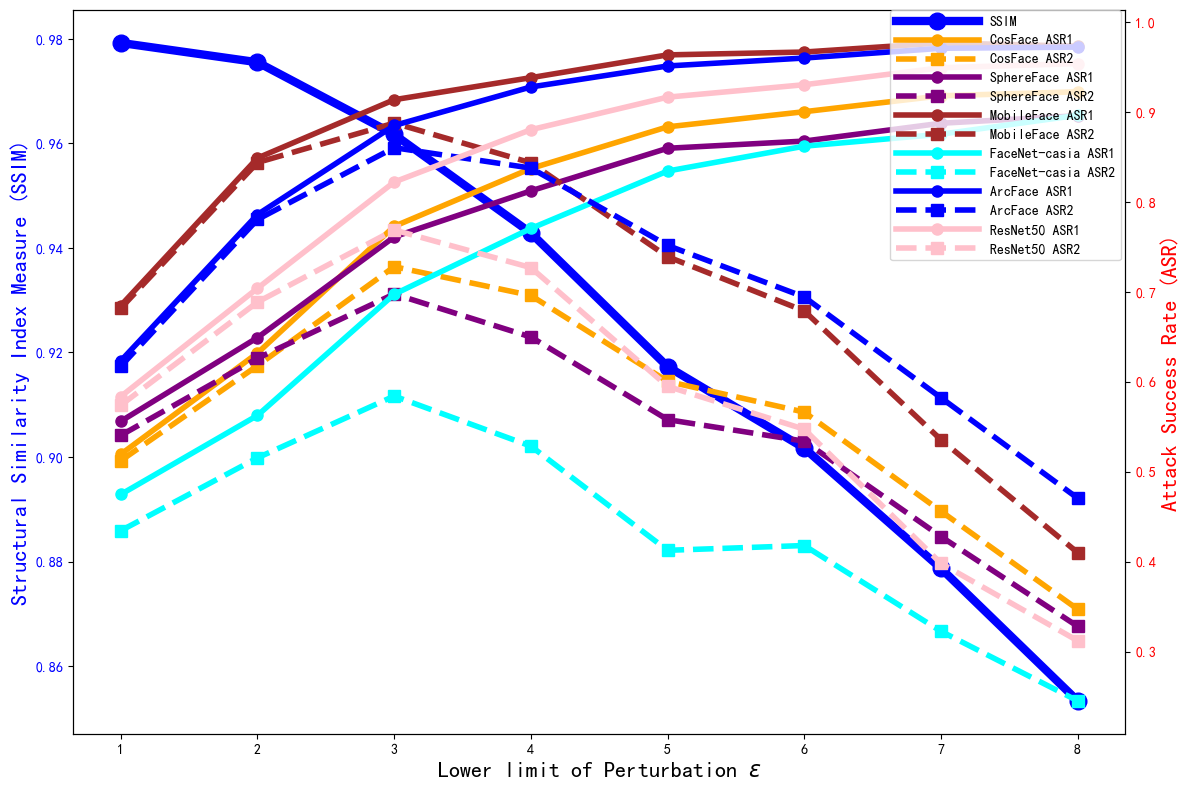

In [95]:
# 不同扰动强度科赛下的攻击性与隐蔽性关系
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# 设置中文字体和负号显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 模拟从字典中读取的攻击数据
attack_data = evaluation_results

# 提取扰动强度
wostloss_models = ['target 1 8白盒 无stloss 990',
                    'target 2 8白盒 无stloss 1490',
                   'target 3 8白盒 无stloss 990',
                   'target 4 8白盒 无stloss 990',
                   'target 5 8白盒 无stloss 990',
                   'target 6 8白盒 无stloss 990',
                   'target 7 8白盒 无stloss 990',
                   'target 8 8白盒 无stloss 990',]
x_index = [int(s[7]) for s in wostloss_models]
# 创建一个图形对象和一个子图对象
fig, ax1 = plt.subplots(figsize=(12, 8))


colors = [
    'orange',      # 橙色
    'purple',      # 紫色
    'brown',       # 棕色
    'cyan',        # 青色
    'blue',      # 黄色
    "pink",        # 粉色
    'red',         # 红色
    'yellow',        # 蓝色
    'green',       # 绿色
]
markers = ['o', 's', '^', 'D', 'P', 'H', 'X', 'v', '<']  # 圆形、方形、三角形等

# 绘制SSIM曲线
average_ssim = [np.mean(attack_data[atk_model]['ArcFace']['average_ssim']) for atk_model in wostloss_models]
ax1.plot(x_index, average_ssim, color='b', marker='o', linestyle='-', linewidth=6, label=f'SSIM', markersize=12)

# 设置左侧Y轴（SSIM）
ax1.set_xlabel('Lower limit of Perturbation $\\epsilon$', fontsize=16)
ax1.set_ylabel('Structural Similarity Index Measure (SSIM)', color='b', fontsize=16)
ax1.tick_params(axis='y', labelcolor='b')

# 创建右侧Y轴并绘制ASR曲线
ax2 = ax1.twinx()
for idx, fr_model_name in enumerate(target_model_name_list[:-3]):
    attack_success_rate1 = [attack_data[atk_model][fr_model_name]['attack_success_rate1'] for atk_model in wostloss_models]
    attack_success_rate2 = [attack_data[atk_model][fr_model_name]['attack_success_rate2'] for atk_model in wostloss_models]
    # attack_success_rate3 = [attack_data[atk_model][fr_model_name]['attack_success_rate3'] for atk_model in wostloss_models]

    # 使用不同的颜色和标记绘制三条曲线，分别对应不同的攻击成功率
    ax2.plot(x_index, attack_success_rate1, color=colors[idx % len(colors)], marker=markers[0], linestyle='-', linewidth=4, label=f'{fr_model_name} ASR1', markersize=8)
    ax2.plot(x_index, attack_success_rate2, color=colors[idx % len(colors)], marker=markers[1], linestyle='--', linewidth=4, label=f'{fr_model_name} ASR2', markersize=8)
    # ax2.plot(x_index, attack_success_rate3, color=colors[idx % len(colors)], marker=markers[2], linestyle=':', linewidth=4, label=f'{fr_model_name} ASR3', markersize=8)

# 设置右侧Y轴（ASR）
ax2.set_ylabel('Attack Success Rate (ASR)', color='r', fontsize=16)
ax2.tick_params(axis='y', labelcolor='r')

# 添加图例
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.74, 0.99), handlelength=6)

# 保存图表为 PNG 文件
os.makedirs("./pic/", exist_ok=True)
plt.savefig('./pic/Figure_6.png', format='png', dpi=300)

# 显示图形
plt.show()



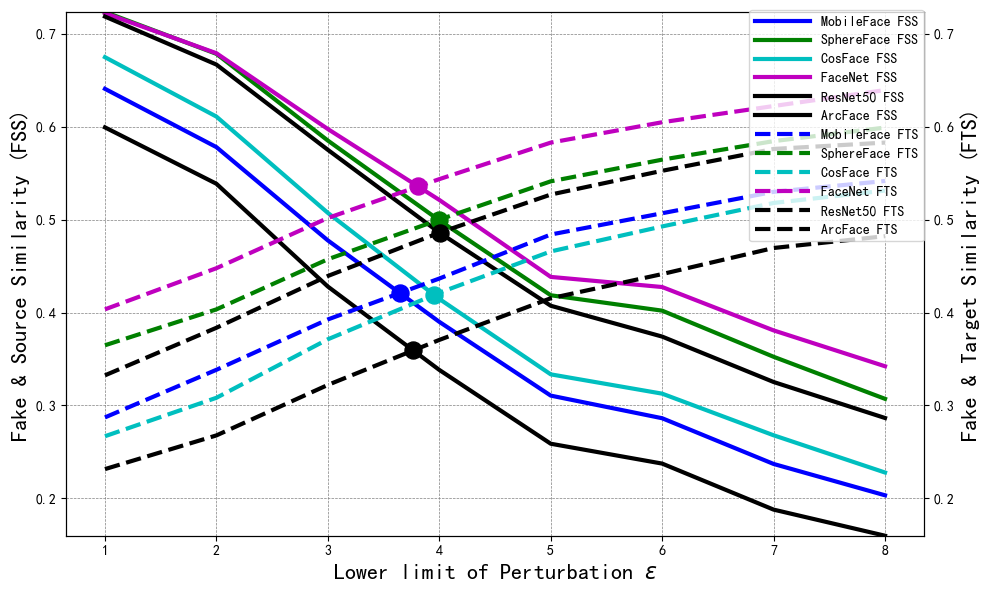

In [96]:
# 进一步说明科赛怎么选取的 为什么选4或5
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# Set font and avoid negative sign display issues
plt.rcParams['font.sans-serif'] = ['SimHei']  # Set font to SimHei for Chinese characters
plt.rcParams['axes.unicode_minus'] = False  # Solve the issue with negative sign display

# Simulated attack data from a dictionary
attack_data = evaluation_results  # Replace with actual data

# Extract perturbation strengths
wostloss_models = ['target 1 8白盒 无stloss 990',
                    'target 2 8白盒 无stloss 1490',
                   'target 3 8白盒 无stloss 990',
                   'target 4 8白盒 无stloss 990',
                   'target 5 8白盒 无stloss 990',
                   'target 6 8白盒 无stloss 990',
                   'target 7 8白盒 无stloss 990',
                   'target 8 8白盒 无stloss 990',]
x_index = [int(s[7]) for s in wostloss_models]

# Extract mean_target_simi and mean_source_simi for each model
mean_target_simi_mobileface = [np.mean(attack_data[atk_model]['MobileFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_mobileface = [np.mean(attack_data[atk_model]['MobileFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_sphereface = [np.mean(attack_data[atk_model]['SphereFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_sphereface = [np.mean(attack_data[atk_model]['SphereFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_cosface = [np.mean(attack_data[atk_model]['CosFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_cosface = [np.mean(attack_data[atk_model]['CosFace']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_facenet = [np.mean(attack_data[atk_model]['FaceNet-casia']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_facenet = [np.mean(attack_data[atk_model]['FaceNet-casia']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_resnet = [np.mean(attack_data[atk_model]['ResNet50']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_resnet = [np.mean(attack_data[atk_model]['ResNet50']['mean_source']) for atk_model in wostloss_models]

mean_target_simi_arcface = [np.mean(attack_data[atk_model]['ArcFace']['mean_target']) for atk_model in wostloss_models]
mean_source_simi_arcface = [np.mean(attack_data[atk_model]['ArcFace']['mean_source']) for atk_model in wostloss_models]

# Define a dictionary to manage data for all models
models = {
    "MobileFace": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['MobileFace']['threshold'],
        "FSS": mean_source_simi_mobileface,
        "FTS": mean_target_simi_mobileface,
        "color": "b",
    },
    "SphereFace": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['SphereFace']['threshold'],
        "FSS": mean_source_simi_sphereface,
        "FTS": mean_target_simi_sphereface,
        "color": "g",
    },
    "CosFace": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['CosFace']['threshold'],
        "FSS": mean_source_simi_cosface,
        "FTS": mean_target_simi_cosface,
        "color": "c",
    },
    "FaceNet": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['FaceNet-casia']['threshold'],
        "FSS": mean_source_simi_facenet,
        "FTS": mean_target_simi_facenet,
        "color": "m",
    },
    "ResNet50": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['ResNet50']['threshold'],
        "FSS": mean_source_simi_resnet,
        "FTS": mean_target_simi_resnet,
        "color": "k",
    },
    "ArcFace": {
        'th_lfw': attack_data['target 2 8白盒 无stloss 1490']['ArcFace']['threshold'],
        "FSS": mean_source_simi_arcface,
        "FTS": mean_target_simi_arcface,
        "color": "k",
    },
}

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(10, 6))

# Create secondary axis for MTS
ax2 = ax1.twinx()

# After plotting both FSS and FTS
# Calculate the combined range of all values
all_y_values = []
for model, data in models.items():
    all_y_values.extend(data["FSS"])
    all_y_values.extend(data["FTS"])

# Find the min and max values from all_y_values
y_min = min(all_y_values)
y_max = max(all_y_values)

# Set the y-limits of both axes to be the same
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

# Add grid lines for better readability
ax1.grid(color='gray', linestyle='--', linewidth=0.5)

# Store intersection points for each model
intersection_points = {}

# Generate wave pattern
def generate_wave_line(y_value, x_range, num_points=100, amplitude=0.005):
    x = np.linspace(min(x_range), max(x_range), num_points)
    y = y_value + amplitude * np.sin(2 * np.pi * np.linspace(0, 3, num_points))  # 3 cycles
    return x, y

# Plot data for each model
for model, data in models.items():
    FSS = data["FSS"]
    FTS = data["FTS"]
    color = data["color"]
    
    # Plot MSS (source similarity) on the primary axis
    ax1.plot(x_index, FSS, f'{color}-', marker='', linewidth=3,zorder=2, label=f'{model} FSS') # marker='^',
    # Plot MTS (target similarity) on the secondary axis
    ax2.plot(x_index, FTS, f'{color}--', marker='', linewidth=3,zorder=2, label=f'{model} FTS') # marker='s', 
    # th_lfw 
    # ax1.plot(x_index, [data["th_lfw"]]*len(x_index), linestyle=':', color=color, linewidth=3, zorder=2, label=f'{model} threshold')

# 最后绘制交点避免被覆盖
for model, data in models.items():
    FSS = data["FSS"]
    FTS = data["FTS"]
    color = data["color"]
    # Find intersection points
    for i in range(len(x_index) - 1):
        if (FSS[i] - FTS[i]) * (FSS[i + 1] - FTS[i + 1]) < 0:  # Check if intersection exists
            # Linear interpolation formula for x_intersect
            x_intersect = (
                x_index[i] * (FTS[i + 1] - FSS[i + 1])
                - x_index[i + 1] * (FTS[i] - FSS[i])
            ) / ((FTS[i + 1] - FSS[i + 1]) - (FTS[i] - FSS[i]))
            # Linear interpolation formula for y_intersect
            y_intersect = FSS[i] + (x_intersect - x_index[i]) * (FSS[i + 1] - FSS[i]) / (x_index[i + 1] - x_index[i])
            # Save the intersection point
            intersection_points[model] = (x_intersect, y_intersect)
            # Highlight the intersection with a marker that has an internal hollow circle
            ax1.scatter(
                x_intersect,
                y_intersect,
                color=color,         # Outer circle color
                edgecolors=color,    # Border color
                s=150,               # Size of the marker
                zorder=5
            )
            continue

# Set axis labels
ax1.set_xlabel('Lower limit of Perturbation $\\epsilon$', fontsize=16)
ax1.set_ylabel('Fake & Source Similarity (FSS)', fontsize=16)
ax1.tick_params(axis='y')

ax2.set_ylabel('Fake & Target Similarity (FTS)', fontsize=16)
ax2.tick_params(axis='y')

# 添加图例
fig.tight_layout()
fig.legend(loc='upper left', bbox_to_anchor=(0.747, 0.99), handlelength=4)
# 保存图表为 PNG 文件
os.makedirs("./pic/", exist_ok=True)
plt.savefig('./pic/Figure_7.png', format='png', dpi=300)

# Show the plot
plt.show()


In [97]:
import re

def get_visual_length(s):
    """计算字符串的视觉宽度：中文字符占2个位置，英文字符和数字占1个位置"""
    visual_length = 0
    for char in s:
        if char=='.':
            visual_length += 1
        if re.match(r'[\u4e00-\u9fa5]', char):  # 判断是否为中文字符
            visual_length += 2  # 中文字符占2个位置
        elif char.isdigit() or char.isalpha():  # 判断是否为数字或字母（大小写字母）
            visual_length += 1  # 英文字符和数字占1个位置
        else:
            visual_length += 1  # 其他字符（如标点符号、空格等）算作1个位置
    return visual_length

def align_string(s, fixed_length, alignment='left'):
    visual_length = get_visual_length(s)
    if visual_length < fixed_length:
        spaces = fixed_length - visual_length
        if alignment == 'left':
            return f"{s}{' ' * spaces}"  # 左对齐，右侧填充空格
        elif alignment == 'right':
            return f"{' ' * spaces}{s}"  # 右对齐，左侧填充空格
        elif alignment == 'center':
            left_space = spaces // 2
            right_space = spaces - left_space
            return f"{' ' * left_space}{s}{' ' * right_space}"  # 居中对齐
        else:
            raise ValueError("Invalid alignment type. Choose 'left', 'right', or 'center'.")
    else:
        return s  # 如果字符串已经超过目标宽度，则不做任何处理

In [98]:
import re
def model_name_format(models):
    res_models=[]
    for model in models:
       # 定义匹配规则
        a_match = re.search(r'target (\d+)', model)
        b_match = re.search(r'(\d+)ssim', model)
        c_match = re.search(r'双身份损失([\d.]+)', model)
        # 提取匹配到的内容
        a = r'$\epsilon$='+f"{a_match.group(1)}"
        b = r'$\zeta$='+f"{int(b_match.group(1))*0.01:.2f}" if b_match else r'w.o.$\zeta$'
        c = r'$\eta$='+f"{c_match.group(1)}" if c_match else r'w.o.$\eta$'
        res_models.append(f'{a} and {b} and {c}')
    return res_models

def show_adv_metrics_table(models, frmodel_name = "ArcFace"):
    formated_models = model_name_format(models)
    FTSs = []
    FSSs = []
    max_len=int(max(get_visual_length(model_name) for model_name in models ))
    print(" " * (max_len-6),'\ttrue_pert\tssim\tpsnr\tmse\tASR1\tASR2\tFSS & FTS')
    for idx,model in enumerate(models):
        print(f"{align_string(model, max_len, alignment='right')}:\t{np.mean(evaluation_results[model][frmodel_name]['true_pert']):.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_ssim'])*100:.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_psnr']):.2f}\t{np.mean(evaluation_results[model][frmodel_name]['average_mse']):.2f}\t{evaluation_results[model][frmodel_name]['attack_success_rate1']*100:.2f}\t{evaluation_results[model][frmodel_name]['attack_success_rate2']*100:.2f}\t{np.mean(evaluation_results[model][frmodel_name]['mean_source'])*100:.2f} & {np.mean(evaluation_results[model][frmodel_name]['mean_target'])*100:.2f}")
        FTSs.append(evaluation_results[model][frmodel_name]['mean_target'])
        FSSs.append(evaluation_results[model][frmodel_name]['mean_source'])
    return FTSs,FSSs

def show_adv_sample_plt(models,frmodel_name = "ArcFace"):
    formated_models = model_name_format(models)
    FTSs,FSSs=show_adv_metrics_table(models=models,frmodel_name = frmodel_name) 
    # 创建图形
    fig, ax = plt.subplots(figsize=(8, 8))
    # 绘制 FTS 对 FSS 的散点图
    for idx,model in enumerate(models):
        ax.scatter(FTSs[idx], FSSs[idx], color=colors[idx%len(colors)], label=formated_models[idx], s=10)
        centroid_x = np.mean(FTSs[idx])
        centroid_y = np.mean(FSSs[idx])
        # 计算点到质心的平均距离
        distances = np.sqrt((FTSs[idx] - centroid_x)**2 + (FSSs[idx] - centroid_y)**2)
        mean_distance = np.mean(distances)
        ax.scatter(
        centroid_x,
        centroid_y,
        color=colors[idx%len(colors)],         # Outer circle color
        edgecolors='g',    # Border color colors[idx%len(colors)]
        linewidths=3,
        s=2000*mean_distance,               # Size of the marker
        zorder=5)
    # 绘制 x = th_lfw 和 y = th_lfw 阈值线
    th_lfw=threshold_lfw[frmodel_name]['cos']
    ax.axvline(x=th_lfw, color='r', linestyle='--', linewidth=3, label=f'x = {th_lfw:.4f} ({frmodel_name} Threshold)')
    ax.axhline(y=th_lfw, color='g', linestyle='--', linewidth=3, label=f'y = {th_lfw:.4f} ({frmodel_name} Threshold)')
    
    # 绘制 y = x 的函数线
    x = np.linspace(-0.1, 1, 10)
    y = x  # y = x
    plt.plot(x, y, color='b', label="y = x", linewidth=3)
    
    plt.xlim(-0.1, 1)
    plt.ylim(-0.1, 1)
    
    
    # 设置坐标轴标签
    ax.set_xlabel('Fake & Target Similarity (FTS)', fontsize=14)
    ax.set_ylabel('Fake & Source Similarity (FSS)', fontsize=14)
    # 设置图例
    fig.legend(loc='upper left', bbox_to_anchor=(0.475, 0.89), handlelength=6, markerscale=3.0)
    # fig.legend(loc='upper right')

    # 保存图表为 PNG 文件
    os.makedirs("./pic/", exist_ok=True)
    plt.savefig('./pic/temp.png', format='png', dpi=300)
    # 显示图形
    plt.show()


In [99]:
# 基于ssim的结构损失的意义是：使生成器能学习到对人脸结构影响更小的扰动模式，从而使得在相同扰动量下取得更好的结构相似性，或在相同的结构相似性下收敛到更高的扰动量，而这意味着对抗人脸能拥有更好的视觉效果或攻击效果。
# 如下表是以上说法的数据验证，表中模型1（扰动量为4&无结构损失）与模型2（扰动量为5&结构损失0.95）的扰动量都接近4、模型3（扰动量5&无结构损失）与模型4（扰动量8&结构损失0.92）的扰动量都接近5，但在psnr和mse不变差的情况下，增加结构损失之后ssim与ASR2都有显著提升。另外模型1和模型4有着相近的ssim,但可以看到起扰动量从4.0上升到了4.94。
models=[
    'target 4 8白盒 无stloss 990',
    'target 5 8白盒 奇怪ssim 95ssim 1660', 
    'target 5 8白盒 无stloss 990',
    'target 8 8白盒 奇怪ssim 92ssim 1490',
]
# CosFace SphereFace MobileFace FaceNet-casia ArcFace ResNet50 testir152
fr_model_name = "ArcFace"
FTSs,FSSs = show_adv_metrics_table(models=models,frmodel_name = fr_model_name)

                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
        target 4 8白盒 无stloss 990:	4.00	94.29	33.30	27.55	92.78	83.77	48.60 & 48.58
target 5 8白盒 奇怪ssim 95ssim 1660:	3.85	96.01	33.78	26.23	89.57	85.93	54.14 & 46.65
        target 5 8白盒 无stloss 990:	5.01	91.73	31.34	43.33	95.12	75.17	40.73 & 52.69
target 8 8白盒 奇怪ssim 92ssim 1490:	4.95	94.35	31.66	43.84	92.72	83.85	47.50 & 50.35


                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                        target 1 8白盒 无stloss 990:	1.83	97.95	40.44	6.11	68.48	68.18	64.06 & 28.72
                       target 2 8白盒 无stloss 1490:	2.18	97.56	38.60	8.20	84.88	84.38	57.79 & 33.84
                        target 3 8白盒 无stloss 990:	3.01	96.17	35.77	15.55	91.37	88.77	47.76 & 39.25
                        target 4 8白盒 无stloss 990:	4.00	94.28	33.31	27.55	93.82	84.35	39.00 & 43.65
                        target 6 8白盒 无stloss 990:	5.85	90.21	30.02	58.89	96.67	67.88	28.62 & 50.68
                        target 7 8白盒 无stloss 990:	6.92	87.79	28.53	82.63	97.68	53.57	23.71 & 52.98
                        target 8 8白盒 无stloss 990:	7.81	85.28	27.59	104.68	97.32	41.02	20.33 & 54.15
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490:	4.31	95.17	32.71	32.52	93.88	91.65	46.34 & 44.79


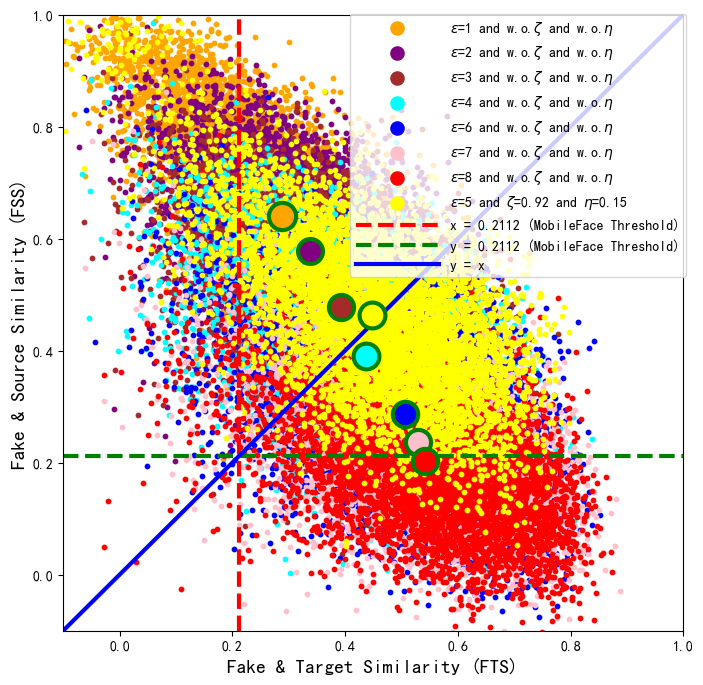

In [100]:
# ssim的消融实验
models=[
    'target 1 8白盒 无stloss 990',
   'target 2 8白盒 无stloss 1490',
   'target 3 8白盒 无stloss 990',
   'target 4 8白盒 无stloss 990',
   'target 6 8白盒 无stloss 990',
   'target 7 8白盒 无stloss 990',
    'target 8 8白盒 无stloss 990',
   # 'target 4 8白盒 奇怪ssim 93ssim 1490',
   # 'target 4 8白盒 奇怪ssim 97ssim 1130',
   # 'target 4 7白盒 奇怪ssim 100ssim 1120',
   # 'target 5 8白盒 无stloss 990',
   # 'target 5 8白盒 92ssim 1160',
   # 'target 5 8白盒 奇怪ssim 95ssim 1660',
   # 'target 8 8白盒 90ssim 1100',
   # 'target 8 8白盒 奇怪ssim 92ssim 1490',
   # 'target 5 8白盒 无stloss 双身份损失0.15 1110',
   #  'target 5 8白盒 无stloss 双身份损失0.15 990',
   'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490',
   # 'target 8 8白盒 奇怪ssim 90ssim 双身份损失0.2 1080',
   # 'target 8 8白盒 91ssim 双身份损失0.3 1150',
]
# CosFace SphereFace MobileFace FaceNet-casia ArcFace ResNet50 testir152
fr_model_name = "MobileFace"
show_adv_sample_plt(models=models,frmodel_name = fr_model_name)

                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490:	4.31	95.17	32.71	32.52	93.88	91.65	46.34 & 44.79


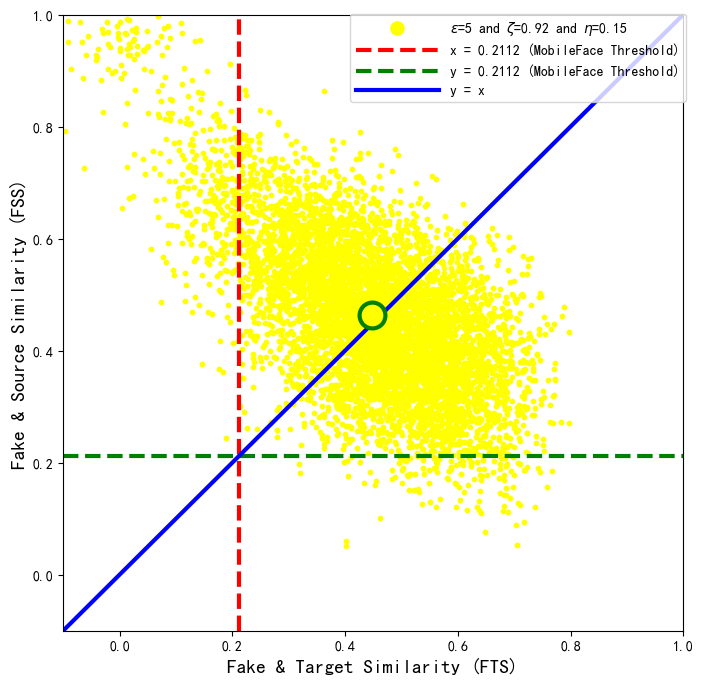

In [92]:
# ssim的消融实验
colors = [
    'yellow',        # 蓝色
]
models=[
    # 'target 1 8白盒 无stloss 990',
   # 'target 2 8白盒 无stloss 1490',
   # 'target 3 8白盒 无stloss 990',
   # 'target 4 8白盒 无stloss 990',
   # 'target 6 8白盒 无stloss 990',
   # 'target 7 8白盒 无stloss 990',
   #  'target 8 8白盒 无stloss 990',
   # 'target 4 8白盒 奇怪ssim 93ssim 1490',
   # 'target 4 8白盒 奇怪ssim 97ssim 1130',
   # 'target 4 7白盒 奇怪ssim 100ssim 1120',
   # 'target 5 8白盒 无stloss 990',
   # 'target 5 8白盒 92ssim 1160',
   # 'target 5 8白盒 奇怪ssim 95ssim 1660',
   # 'target 8 8白盒 90ssim 1100',
   # 'target 8 8白盒 奇怪ssim 92ssim 1490',
   # 'target 5 8白盒 无stloss 双身份损失0.15 1110',
   #  'target 5 8白盒 无stloss 双身份损失0.15 990',
   'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490',
   # 'target 8 8白盒 奇怪ssim 90ssim 双身份损失0.2 1080',
   # 'target 8 8白盒 91ssim 双身份损失0.3 1150',
]
# CosFace SphereFace MobileFace FaceNet-casia ArcFace ResNet50 testir152
fr_model_name = "MobileFace"
show_adv_sample_plt(models=models,frmodel_name = fr_model_name)

                                              	true_pert	ssim	psnr	mse	ASR1	ASR2	FSS & FTS
                        target 1 8白盒 无stloss 990:	1.83	97.95	40.44	6.11	68.48	68.18	64.06 & 28.72
                       target 2 8白盒 无stloss 1490:	2.18	97.56	38.60	8.20	84.88	84.38	57.79 & 33.84
                        target 3 8白盒 无stloss 990:	3.01	96.17	35.77	15.55	91.37	88.77	47.76 & 39.25
                        target 4 8白盒 无stloss 990:	4.00	94.28	33.31	27.55	93.82	84.35	39.00 & 43.65
                        target 5 8白盒 无stloss 990:	5.01	91.83	31.37	43.32	96.35	73.92	31.06 & 48.39
                        target 6 8白盒 无stloss 990:	5.85	90.21	30.02	58.89	96.67	67.88	28.62 & 50.68
                        target 7 8白盒 无stloss 990:	6.92	87.79	28.53	82.63	97.68	53.57	23.71 & 52.98
                        target 8 8白盒 无stloss 990:	7.81	85.28	27.59	104.68	97.32	41.02	20.33 & 54.15
target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490:	4.31	95.17	32.71	32.52	93.88	91.65	46.34 & 44.79


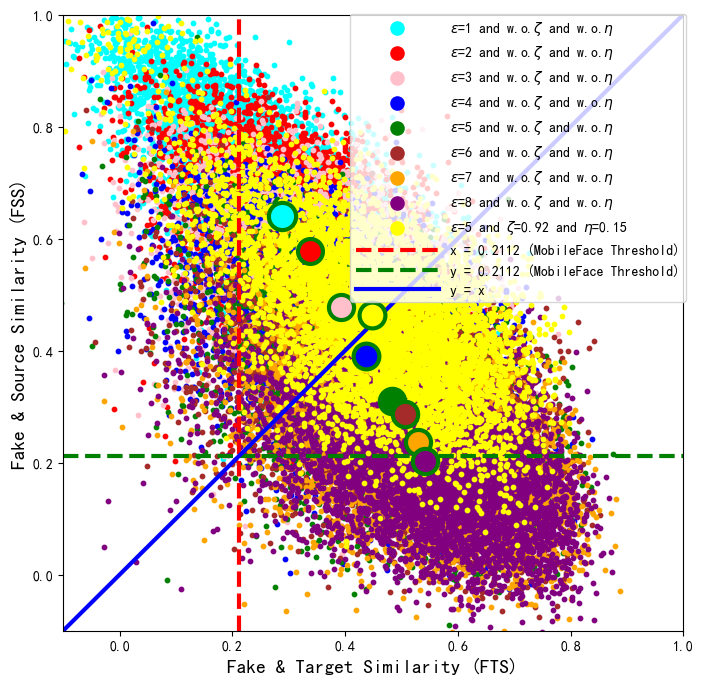

In [17]:
colors = [
    'cyan',        # 青色
    'red',      # 黄色
    "pink",        # 粉色
    'blue',        # 蓝色
    'green',       # 绿色
    'brown',         # 红色
    'orange',      # 橙色
    'purple',      # 紫色
    'yellow',       # 棕色
]
models=[
    'target 1 8白盒 无stloss 990',
    'target 2 8白盒 无stloss 1490',
    'target 3 8白盒 无stloss 990',
    'target 4 8白盒 无stloss 990',
    'target 5 8白盒 无stloss 990',
    'target 6 8白盒 无stloss 990',
    'target 7 8白盒 无stloss 990',
    'target 8 8白盒 无stloss 990',
    'target 5 8白盒 奇怪ssim 92ssim 双身份损失0.15 2490',
]
# CosFace SphereFace MobileFace FaceNet-casia ArcFace ResNet50 testir152
fr_model_name = "MobileFace"
show_adv_sample_plt(models=models,frmodel_name = fr_model_name)